## Домашнее задание 5

In [2]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import re

class Account:
    
    __account_counter = 1000
    
    def __init__(self, account_holder: str, balance: float = 0):

        if not self._is_valid_name(account_holder):
            raise ValueError(
                "Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв, "
                "кириллицей или латиницей."
            )

        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным")
        
        self.holder = account_holder
        self.account_number = f"ACC-{Account.__account_counter}"

        Account.__account_counter += 1
        self.__balance = balance
        self.operations_history = []
        self.datetime_format = '%Y-%m-%d %H:%M:%S'
        
        # Записываем операцию создания счёта
        if balance > 0:
            self.operations_history.append({
                'operation': 'Открытие счёта',
                'amount': balance,
                'balance': self.__balance,
                'datetime': datetime.now().strftime(self.datetime_format),
                'status': 'success'
            })
    
    def get_balance(self) -> float:
        return self.__balance
    
    def deposit(self, amount: float) -> None:
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной")
        
        self.__balance += amount
        self.operations_history.append({
            'operation': 'Пополнение',
            'amount': amount,
            'balance': self.__balance,
            'datetime': datetime.now().strftime(self.datetime_format),
            'status': 'success'
        })
    
    def withdraw(self, amount: float) -> None:
        if amount > self.__balance:
            # фиксируем неудачную попытку
            self.operations_history.append({
                'operation': 'withdraw',
                'amount': amount,
                'balance': self.__balance,
                'datetime': datetime.now().strftime(self.datetime_format),
                'status': 'fail'
            })
            raise ValueError("Недостаточно средств на счёте")

        # успешное снятие
        self.__balance -= amount
        self.operations_history.append({
            'operation': 'withdraw',
            'amount': amount,
            'balance': self.__balance,
            'datetime': datetime.now().strftime(self.datetime_format),
            'status': 'success'
        })
    
    def plot_history(self):
        """
        Визуализация истории операций
        """
        if not self.operations_history:
            print("История операций пуста. Нет данных для визуализации.")
            return
        
        df = pd.DataFrame(self.operations_history)
        
        plt.figure(figsize=(12, 6))
        plt.plot(df['datetime'], df['balance'], marker='o', linewidth=2, markersize=8, color="#00B3FF", markerfacecolor="#00FF37")
        plt.title(f'История изменения баланса счёта №{self.account_number}\nВладелец: {self.holder}', fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Дата и время операции', fontsize=12, fontweight='bold')
        plt.ylabel('Баланс (₽)', fontsize=12, fontweight='bold')
        plt.grid(True, alpha=0.3, linestyle='--') 
        plt.xticks(rotation=45, ha='right')
        ax = plt.gca()
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
        
        for idx, row in df.iterrows():
            plt.annotate(f'{row["balance"]:.0f}', 
                        xy=(row['datetime'], row['balance']),
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', fontsize=9, color="#000000")
        
        plt.tight_layout()
        plt.show()
    
    def get_history(self) -> list:
        return self.operations_history.copy()
    
    def account_counter(self):
        return Account.__account_counter
    
    def top_transactions(self, n: int = 5):
        """
        Выводит последние n крупных успешных операций по сумме.
        """
        top_ops = sorted(
            [op for op in self.operations_history 
            if op['status'] == 'success' and op['operation'] in ('Пополнение', 'withdraw', 'deposit (apply_interest)')],
            key=lambda x: x['amount'], reverse=True
        )[:n]

        print(f"Топ {n} крупных операций по счёту {self.account_number}:")
        for op in top_ops:
            print(f"{op['datetime']} | {op['operation']} | Сумма: {op['amount']:.2f} | Баланс: {op['balance']:.2f}")


    
    def __str__(self) -> str:
        """Строковое представление счёта"""
        return f"Счёт {self.account_number}, Владелец: {self.holder}, Баланс: {self.__balance:.2f}"
    
    @staticmethod
    def _is_valid_name(name: str) -> bool:
        """
        Проверяет, что имя в формате 'Имя Фамилия', обе части начинаются с заглавной буквы.
        Допускается кириллица и латиница.
        """
        pattern = re.compile(r"^([А-ЯЁ][а-яё]+|[A-Z][a-z]+)\s([А-ЯЁ][а-яё]+|[A-Z][a-z]+)$")
        return bool(pattern.match(name))

Счёт ACC-1002, Владелец: Иван Иванов, Баланс: 1000.00
Счёт ACC-1003, Владелец: Мария Петрова, Баланс: 500.00
Счёт ACC-1004, Владелец: Алексей Сидоров, Баланс: 0.00

Операции со счётом Иванова
После пополнения: 4500
После снятия: 4200

История операций
{'operation': 'Открытие счёта', 'amount': 1000, 'balance': 1000, 'datetime': '2025-10-30 19:46:38', 'status': 'success'}
{'operation': 'Пополнение', 'amount': 3500, 'balance': 4500, 'datetime': '2025-10-30 19:46:38', 'status': 'success'}
{'operation': 'withdraw', 'amount': 300, 'balance': 4200, 'datetime': '2025-10-30 19:46:39', 'status': 'success'}

ВИЗУАЛИЗАЦИЯ ИСТОРИИ ОПЕРАЦИЙ


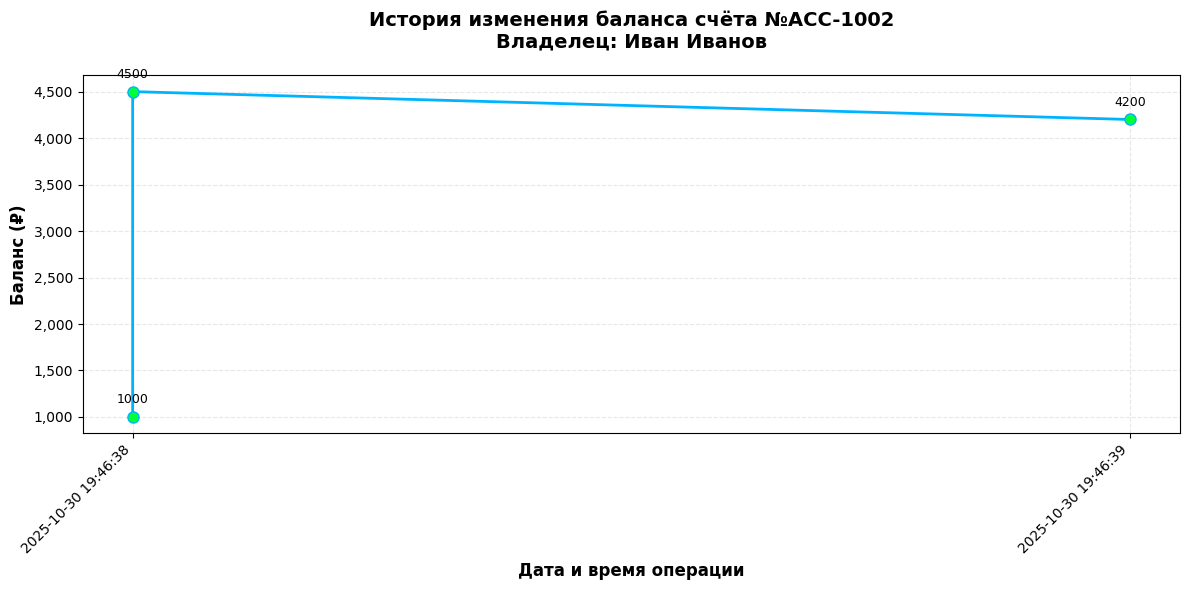

In [10]:

import time

account1 = Account("Иван Иванов", 1000)
print(account1)

account2 = Account("Мария Петрова", 500)
print(account2)

account3 = Account("Алексей Сидоров")
print(account3)


print("\nОперации со счётом Иванова")
account1.deposit(3500)
print(f"После пополнения: {account1.get_balance()}")

time.sleep(1)

account1.withdraw(300)
print(f"После снятия: {account1.get_balance()}")

time.sleep(1)

print("\nИстория операций")
for operation in account1.get_history():
    print(operation)

print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ ИСТОРИИ ОПЕРАЦИЙ")
print("="*50)
account1.plot_history()

In [9]:
account_error = Account("Тест Тестович", -100)

ValueError: Начальный баланс не может быть отрицательным

In [8]:
account_error = Account("Тест", 100)

ValueError: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв, кириллицей или латиницей.

In [11]:
account1.withdraw(10000)

ValueError: Недостаточно средств на счёте

In [12]:
account1.get_history()

[{'operation': 'Открытие счёта',
  'amount': 1000,
  'balance': 1000,
  'datetime': '2025-10-30 19:46:38',
  'status': 'success'},
 {'operation': 'Пополнение',
  'amount': 3500,
  'balance': 4500,
  'datetime': '2025-10-30 19:46:38',
  'status': 'success'},
 {'operation': 'withdraw',
  'amount': 300,
  'balance': 4200,
  'datetime': '2025-10-30 19:46:39',
  'status': 'success'},
 {'operation': 'withdraw',
  'amount': 10000,
  'balance': 4200,
  'datetime': '2025-10-30 19:46:45',
  'status': 'fail'}]

### Задание 2

In [ ]:
import json
import csv

class CheckingAccount(Account):
    account_type = "Checking Account"


class SavingsAccount(Account):
    account_type = "Saving Account"
    
    def withdraw(self, amount: float) -> None:
        balance = self.get_balance()
        if balance - amount <= balance/2:
            super().withdraw(amount)

    def depositFrom(self, amount: float, account: CheckingAccount) -> None:
        account.withdraw(amount)
        return super().deposit(amount)
    
    def apply_interest(self, rate: float = 7) -> None:
        balance = self.get_balance()
        interest = balance * (rate / 100)
        self.deposit(interest)
        self.operations_history[-1]['operation'] = 'Пополнение (apply_interest)'
    

    


personSaving = SavingsAccount("Георгий Победоносец", 1000)
personSaving.apply_interest(7)
personChecking = CheckingAccount("Георгий Победоносец", 1000)

In [ ]:
personSaving.depositFrom(500, personChecking) # Перевод средств с одного счета на другой

In [22]:
personSaving.get_balance()

1570.0

In [23]:
personSaving.get_history()

[{'operation': 'Открытие счёта',
  'amount': 1000,
  'balance': 1000,
  'datetime': '2025-10-30 19:55:39',
  'status': 'success'},
 {'operation': 'Пополнение',
  'amount': 70.0,
  'balance': 1070.0,
  'datetime': '2025-10-30 19:55:39',
  'status': 'success'},
 {'operation': 'Пополнение (apply_interest)',
  'amount': 70.0,
  'balance': 1070.0,
  'datetime': '2025-10-30 19:55:39',
  'status': 'success'},
 {'operation': 'Пополнение',
  'amount': 500,
  'balance': 1570.0,
  'datetime': '2025-10-30 19:55:41',
  'status': 'success'}]

In [24]:
personChecking.get_balance()

500

In [25]:
personChecking.get_history()

[{'operation': 'Открытие счёта',
  'amount': 1000,
  'balance': 1000,
  'datetime': '2025-10-30 19:55:39',
  'status': 'success'},
 {'operation': 'withdraw',
  'amount': 500,
  'balance': 500,
  'datetime': '2025-10-30 19:55:41',
  'status': 'success'}]

### Задание 3